In [1]:
# cargar el modelo entrenado previamente 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# dataset
df = pd.read_csv('../datos/partidos_cebollitas_fe82a1a4-e109-41b1-8b78-d9b4341dacaf.csv')
df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
x = df[['posesion_local (%)', 'tiros_arco_local']]
y = df['diferencia_goles']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# modelo base 
modelo = LinearRegression()
modelo.fit(x_train, y_train)
y_pred= modelo.predict(x_test)


In [2]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
 
print(f'RMSE: {rmse:.2f}')
print(f"R²: {r2:.2f}")

RMSE: 2.23
R²: -0.03


In [3]:
if r2 < 0:
    print('El modelo explica la varianza, es peor que adivinar')
elif r2 < 0.3:
    print('El modelo explica muy poco, posible underfitting')
else: 
    print('El nivel de explicacion es pasable 👍')

El modelo explica la varianza, es peor que adivinar


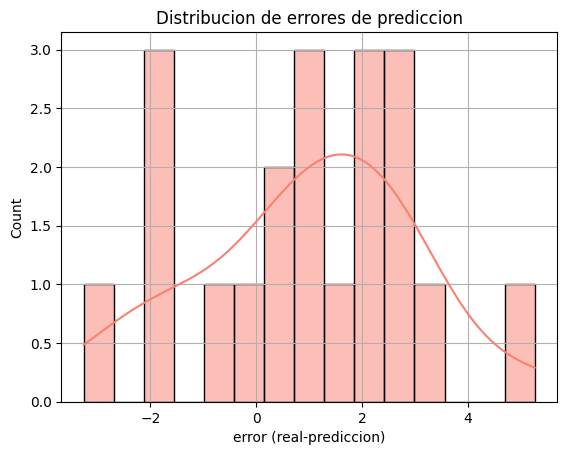

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_test - y_pred, bins=15, kde=True, color ='salmon')
plt.title('Distribucion de errores de prediccion')
plt.xlabel('error (real-prediccion)')
plt.grid(True)
plt.show()